# IZ-DCE Demo

Import

In [1]:
from __future__ import annotations

import os

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pyiqa
import torch
from scipy.stats import skew
from torch import Tensor

from iz_dce import iz_dce
from mon.core import Path, Size
from mon.dataset import transform as T
from mon.models.enhance.zero_dce import zero_dce
from mon.ops import to_image_array, write_image

/home/longpham/miniconda3/envs/mon/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/longpham/miniconda3/envs/mon/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


[11:35:29] `mon` loaded in: 0.5000 seconds.                                                          ]8;id=315591;file:///home/longpham/10_workspace/11_code/mon/libs/mon/src/mon/__init__.py\__init__.py]8;;\:]8;id=151062;file:///home/longpham/10_workspace/11_code/mon/libs/mon/src/mon/__init__.py#29\29]8;;\

Setup environment

In [2]:
current_dir = Path(os.getcwd())
root_dir = current_dir.parents[0]
data_dir = current_dir / "demo"
output_dir = current_dir / "demo"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = {}

# Debug
print(f"Device: {device}")

Device: cuda


Resolve I/O

In [3]:
# image_name = "993_UHD_LL"
# image_name = "1513_UHD_LL"
# image_name = "a0016-jmac_MG_0795"
image_name = "lol_v1_22"
# image_name = "lsrw_2038"
# image_name = "sice_1"

image_file = (data_dir / image_name / f"{image_name}").image_file
depth_file = (data_dir / image_name / f"{image_name}_depth").image_file
target_file = (data_dir / image_name / f"{image_name}_target").image_file

# Load data
image = cv2.imread(str(image_file))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

depth = cv2.imread(str(depth_file), cv2.IMREAD_GRAYSCALE)
if depth.ndim == 2:
    depth = np.expand_dims(depth, axis=-1)

target = cv2.imread(str(target_file))
target = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)

# Debug
print(f"Image shape : {image.shape}")
print(f"Depth shape : {depth.shape}")
print(f"target shape: {target.shape}")
assert image.shape[0:2] == depth.shape[0:2], "'image' and 'depth' must have the same resolution."

Image shape : (400, 600, 3)
Depth shape : (400, 600, 1)
target shape: (400, 600, 3)


Pre-process

In [4]:
# Normalize and convert to torch.Tensor
transform = T.Compose([
    # T.Resize(512, 512),
    T.NormalizeWithMask(normalization="min_max"),
    T.ToTensorV2(transpose_mask=True),
], additional_targets={"target": "image"})
transformed = transform(image=image, mask=depth, target=target)

image_t = transformed["image"]
depth_t = transformed["mask"]
target_t = transformed["target"]

image_t = image_t.unsqueeze(0).to(device)
depth_t = depth_t.unsqueeze(0).to(device)
target_t = target_t.unsqueeze(0).to(device)

# Debug
print(f"Image shape : {image_t.shape}. Type: {image_t.dtype}. Device: {image_t.device}.")
print(f"Depth shape : {depth_t.shape}. Type: {depth_t.dtype}. Device: {depth_t.device}.")
print(f"target shape: {target_t.shape}. Type: {target_t.dtype}. Device: {target_t.device}.")

Image shape : torch.Size([1, 3, 400, 600]). Type: torch.float32. Device: cuda:0.
Depth shape : torch.Size([1, 1, 400, 600]). Type: torch.float32. Device: cuda:0.
target shape: torch.Size([1, 3, 400, 600]). Type: torch.float32. Device: cuda:0.


In [5]:
def analyze_noise_distribution(image: Tensor, target: Tensor | None = None):
    """Analyzes whether the noise in a tensor is zero-mean and symmetrical.
    Expects tensors in shape [B, C, H, W] with values 0.0 to 1.0.
    """
    # 1. Extract the Noise
    if target is not None:
        # We have ground truth: pure residual noise
        noise = (image - target).cpu().numpy().flatten()
    else:
        # No ground truth: We crop a known "flat" area (e.g., top-left 50x50 pixels)
        # You should adjust these crop coordinates to a flat wall/sky in your image
        patch = image[:, :, 0:50, 0:50].cpu().numpy().flatten()
        noise = patch - np.mean(patch)

    # 2. Calculate Statistical Properties
    # A perfect symmetrical distribution has a mean of 0.0 and a skewness of 0.0
    noise_mean = np.mean(noise)
    noise_skew = skew(noise)

    print(f"--- Noise Statistics ---")
    print(f"Mean (Should be ~0.0): {noise_mean:.6f}")
    print(f"Skewness (Should be ~0.0): {noise_skew:.6f}")

    if abs(noise_skew) > 0.5:
        print("Warning: The noise is highly asymmetrical (likely clipped by low-light).")
    elif abs(noise_skew) > 0.1:
        print("Note: The noise is slightly asymmetrical.")
    else:
        print("Pass: The noise is approximately symmetrical.")

    # 3. Plot the Histogram
    plt.figure(figsize=(6, 3))

    # We use 100 bins and limit the range to +/- 0.2 (since image max is 1.0)
    plt.hist(noise, bins=100, range=(-0.2, 0.2), density=True, alpha=0.7, color='blue')

    plt.axvline(x=0, color='red', linestyle='--', label='Zero Mean')
    plt.axvline(x=noise_mean, color='green', linestyle='-', label=f'Actual Mean ({noise_mean:.4f})')

    plt.title(f"Noise Distribution (Skewness: {noise_skew:.3f})")
    plt.xlabel("Pixel Value Difference")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

Process

In [6]:
def test_baseline(image_: Tensor, depth_: Tensor):
    global results, device

    model = zero_dce(verbose=False).to(device)
    weights = Path("/home/longpham/10_workspace/11_code/mon/zoo/cv/enhance/zero_dce/zero_dce/sice_me/zero_dce_sice_me.pt")
    if weights.is_weights_file(exists=True):
        model.load_state_dict(torch.load(str(weights)))
    model.eval()

    outputs = model.forward(image_)
    enhanced = outputs["enhanced"]

    results["zero_dce"] = {"enhanced": enhanced}

In [7]:
def test_arch(image_: Tensor, depth_: Tensor, use_depth: bool, version: str = "v1"):
    global results, device

    # Define model
    model = iz_dce(use_depth=use_depth, verbose=False).to(device)
    weights = Path(f"/home/longpham/10_workspace/11_code/mon/projects/dev/run/train/iz_dce/iz_dce_sice_me_{version}/best_psnr.pt")
    if weights.is_weights_file(exists=True):
        model.load_state_dict(torch.load(str(weights)))
    model.eval()

    if use_depth:
        outputs = model.forward(image_, depth_)
    else:
        outputs = model.forward(image_)
    enhanced = outputs["enhanced"]

    results[f"iz_dce_{version}"] = {"enhanced": enhanced.detach()}

In [8]:
test_baseline(image_t, depth_t)

In [9]:
test_arch(image_t, depth_t, True, "v1")
test_arch(image_t, depth_t, True, "v2")
test_arch(image_t, depth_t, False, "v3")
test_arch(image_t, depth_t, False, "v4")

--- Noise Statistics ---
Mean (Should be ~0.0): -0.281374
Skewness (Should be ~0.0): 1.192872


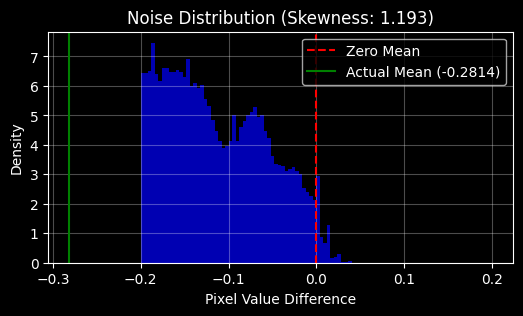

--- Noise Statistics ---
Mean (Should be ~0.0): -0.017933
Skewness (Should be ~0.0): -0.680239


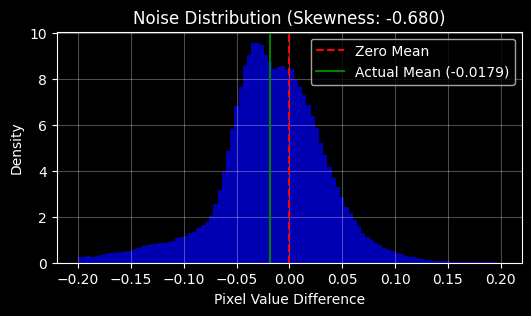

In [10]:
analyze_noise_distribution(image_t, target_t)
# analyze_noise_distribution(results["iz_dce_v3"]["enhanced"], target_t)
analyze_noise_distribution(results["iz_dce_v4"]["enhanced"], target_t)

Measure metrics

In [11]:
def measure_metrics(key: str = "enhanced"):
    global target_t, results, device

    # Create metrics with default settings
    psnr_metric = pyiqa.create_metric("psnr", device=device)
    ssim_metric = pyiqa.create_metric("ssim", device=device)
    lpips_metric = pyiqa.create_metric("lpips", device=device)
    niqe_metric = pyiqa.create_metric("niqe", device=device)
    brisque_metric = pyiqa.create_metric("brisque", device=device)

    # Concatenate results for visualization
    titles = ["image"]
    images = [image]
    for k1, v1 in results.items():
        titles.append(k1)
        images.append(v1[key])

    # Measure metrics
    target_ = target_t.to(device)
    for i in range(1, len(images)):
        if isinstance(images[i], Tensor):
            img_ = images[i].to(device)
        else:
            img_ = images[i]

        psnr_value = psnr_metric(img_, target_).item()
        ssim_value = ssim_metric(img_, target_).item()
        lpips_value = lpips_metric(img_, target_).item()
        niqe_value = niqe_metric(img_).item()
        brisque_value = brisque_metric(img_).item()

        print(
            f"{titles[i]:15s} "
            f"| PSNR: {psnr_value:6.2f} "
            f"| SSIM: {ssim_value:6.4f} "
            f"| LPIPS: {lpips_value:6.4f} "
            f"| NIQE: {niqe_value:6.4f} "
            f"| BRISQUE: {brisque_value:6.4f} "
        )

In [12]:
measure_metrics("enhanced")

Loading pretrained model LPIPS from /home/longpham/.cache/torch/hub/checkpoints/LPIPS_v0.1_alex-df73285e.pth
zero_dce        | PSNR:  19.90 | SSIM: 0.7555 | LPIPS: 0.3050 | NIQE: 2.7943 | BRISQUE: 20.0215 
iz_dce_v1       | PSNR:  24.89 | SSIM: 0.7742 | LPIPS: 0.2610 | NIQE: 2.8567 | BRISQUE: 17.8002 
iz_dce_v2       | PSNR:  21.74 | SSIM: 0.7918 | LPIPS: 0.2486 | NIQE: 3.0056 | BRISQUE: 17.5643 
iz_dce_v3       | PSNR:  25.04 | SSIM: 0.7888 | LPIPS: 0.2589 | NIQE: 2.8931 | BRISQUE: 17.1263 
iz_dce_v4       | PSNR:  24.97 | SSIM: 0.7904 | LPIPS: 0.2563 | NIQE: 2.8878 | BRISQUE: 17.4211 


Post-process

In [13]:
def postprocess():
    global image, results

    size0 = Size.from_value(image)

    # Convert outputs to numpy arrays
    for k1, v1 in results.items():
        for k2, v2 in v1.items():
            v2 = to_image_array(v2)

            size1 = Size.from_value(v2)
            if size0 != size1:
                v2 = cv2.resize(v2, size0.wh)

            results[k1][k2] = v2

In [14]:
postprocess()

Visualize

In [15]:
# Setup matplotlib
plt.rcParams["figure.autolayout"] = True

In [16]:
def compare_results(key: str = "enhanced"):
    global results

    # Concatenate results for visualization
    titles = ["image", "depth", "target"]
    images = [image, depth, target]
    for k1, v1 in results.items():
        titles.append(k1)
        images.append(v1[key])

    # Create a grid of images
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))
    for i, ax in enumerate(axes):
        ax.imshow(images[i])
        ax.set_title(titles[i])
        ax.axis("off")

    # Adjust the layout and show the plot
    plt.tight_layout()  # Adjust layout to prevent title overlap
    plt.show()

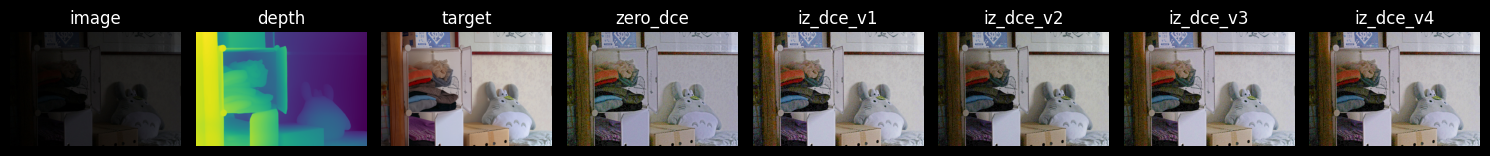

In [17]:
compare_results(key="enhanced")

Save

In [18]:
def save():
    global results

    for k1, v1 in results.items():
        for k2, v2 in v1.items():
            save_file = output_dir / f"{image_name}_debug" / f"{image_name}_{k1}_{k2}.jpg"
            write_image(v2, save_file)

In [19]:
save()